All Dependencies

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from sklearn.model_selection import train_test_split
from glob import glob

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Mount Drive (Execute only if using Colab)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load Dataset

LR: (9000, 75, 75, 1), HR: (9000, 150, 150, 1)
Range — LR: [0.0000, 1.0000], HR: [0.0016, 0.9610]


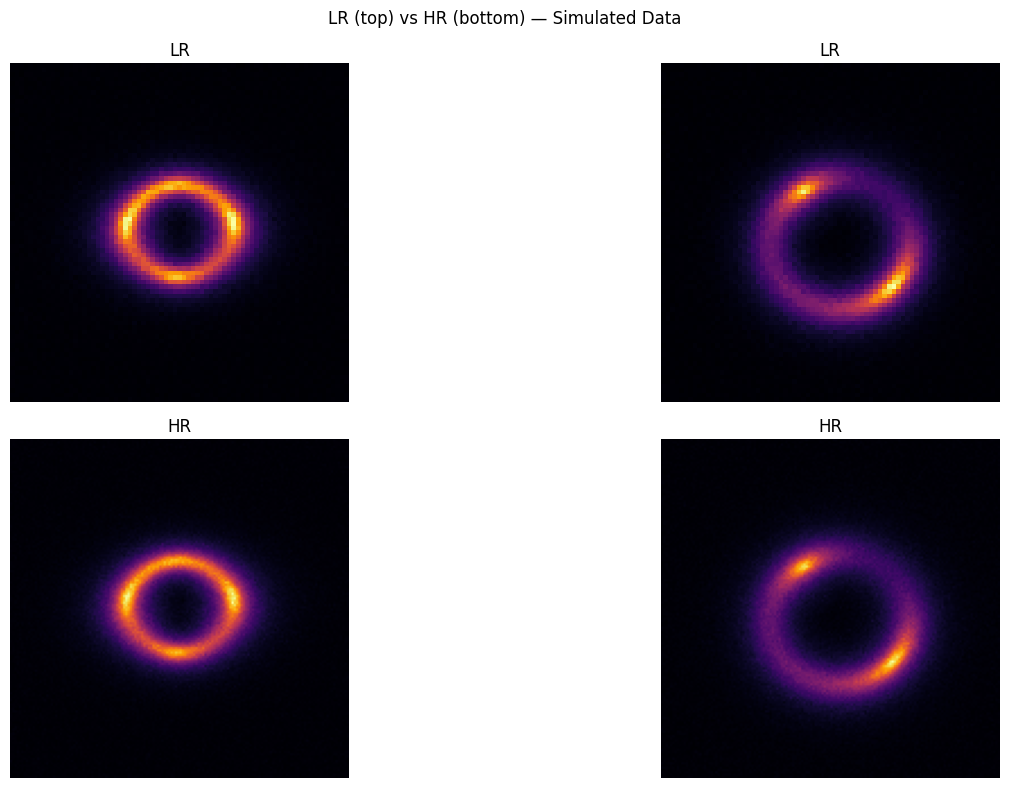

In [ ]:
file_path = "/content/drive/MyDrive/Tasks/SR_1/Dataset"

# Initialise parameters
BATCH_SIZE = 16
PRETRAIN_EPOCHS = 20
GAN_EPOCHS = 30
SEED = 42
LAMBDA_PIXEL = 1.0
LAMBDA_ADV = 0.001
np.random.seed(SEED)
tf.random.set_seed(SEED)

def load_dataset(dataset_dir):

  lr_dict = {}
  hr_dict = {}
  LR = []
  HR = []

  for d in os.listdir(dataset_dir):
    if d == "LR":
      lr_dir = os.path.join(dataset_dir, d)
      for img in os.listdir(lr_dir):
        if img.endswith(".npy"):
          img_path = os.path.join(lr_dir, img)
          img_data = np.load(img_path)
          img_data = np.transpose(img_data, (1, 2, 0))
          lr_dict[img] = img_data
    if d == "HR":
      hr_dir = os.path.join(dataset_dir, d)
      for img in os.listdir(hr_dir):
        if img.endswith(".npy"):
          img_path = os.path.join(hr_dir, img)
          img_data = np.load(img_path)
          img_data = np.transpose(img_data, (1, 2, 0))
          hr_dict[img] = img_data

  for fname in lr_dict:
    if fname in hr_dict:
      LR.append(lr_dict[fname])
      HR.append(hr_dict[fname])

  LR = np.array(LR, dtype=np.float32)
  HR = np.array(HR, dtype=np.float32)

  # Normalize to [0, 1]
  global_min = min(LR.min(), HR.min())
  global_max = max(LR.max(), HR.max())
  LR = (LR - global_min) / (global_max - global_min + 1e-8)
  HR = (HR - global_min) / (global_max - global_min + 1e-8)

  #90-10 split
  hr_train,hr_test,lr_train,lr_test = train_test_split(HR,LR,test_size=0.10,random_state=SEED)
  return hr_train,hr_test,lr_train,lr_test

hr_train, hr_test, lr_train, lr_test = load_dataset(file_path)

print(f"LR: {lr_train.shape}, HR: {hr_train.shape}")
print(f"Range — LR: [{lr_train.min():.4f}, {lr_train.max():.4f}], HR: [{hr_train.min():.4f}, {hr_train.max():.4f}]")

fig,axes=plt.subplots(2,2,figsize=(16,8))

for i in range(2):
    axes[0,i].imshow(lr_test[i,:,:,0], cmap='inferno')
    axes[0,i].set_title("LR")
    axes[0,i].axis('off')

    axes[1,i].imshow(hr_test[i,:,:,0], cmap='inferno')
    axes[1,i].set_title("HR")
    axes[1,i].axis('off')

plt.suptitle("LR (top) vs HR (bottom) — Simulated Data")
plt.tight_layout()
plt.show()

Build Model

In [5]:
### BUILD GENERATOR — 75×75×1 → 150×150×1
def res_block(x, f=64):
    s = x
    x = layers.Conv2D(f, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.PReLU(shared_axes=[1,2])(x)
    x = layers.Conv2D(f, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    return layers.Add()([x, s])

inp = keras.Input(shape=(75, 75, 1))
x = layers.Conv2D(64, 9, padding='same')(inp)
x = layers.PReLU(shared_axes=[1,2])(x)
skip = x

for _ in range(16):
    x = res_block(x, 64)

x = layers.Conv2D(64, 3, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Add()([x, skip])

# Single 2× upsample via pixel shuffle
x = layers.Conv2D(256, 3, padding='same')(x)
x = layers.Lambda(lambda t: tf.nn.depth_to_space(t, 2))(x)
x = layers.PReLU(shared_axes=[1,2])(x)

out = layers.Conv2D(1, 9, padding='same', activation='sigmoid')(x)

generator = keras.Model(inp, out, name="Generator")

### BUILD DISCRIMINATOR
def d_block(x, f, s=1, bn=True):
    x = layers.Conv2D(f, 3, strides=s, padding='same')(x)
    if bn: x = layers.BatchNormalization()(x)
    return layers.LeakyReLU(0.2)(x)

d_inp = keras.Input(shape=(150, 150, 1))
dx = d_block(d_inp, 64, 1, bn=False)
dx = d_block(dx, 64, 2)
dx = d_block(dx, 128, 1)
dx = d_block(dx, 128, 2)
dx = d_block(dx, 256, 1)
dx = d_block(dx, 256, 2)
dx = d_block(dx, 512, 1)
dx = d_block(dx, 512, 2)
dx = layers.Flatten()(dx)
dx = layers.Dense(1024)(dx)
dx = layers.LeakyReLU(0.2)(dx)
d_out = layers.Dense(1, activation='sigmoid')(dx)

discriminator = keras.Model(d_inp, d_out, name="Discriminator")

print(f"Generator: {generator.count_params():,} params")
print(f"Discriminator: {discriminator.count_params():,} params")

Generator: 1,386,369 params
Discriminator: 57,122,497 params


Pre-Train Model

In [6]:
def compute_metrics(hr, sr):
    mse = np.mean((hr - sr)**2, axis=(1,2,3))
    psnr = 10 * np.log10(1.0 / (mse + 1e-10))
    ssim = tf.image.ssim(hr, sr, max_val=1.0).numpy()
    return np.mean(mse), np.mean(psnr), np.mean(ssim)

generator.compile(optimizer=optimizers.Adam(1e-4), loss='mae')
generator.fit(lr_train, hr_train, validation_data=(lr_test, hr_test),
    epochs=PRETRAIN_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
               keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)], verbose=1)

m, p, s = compute_metrics(hr_test, generator.predict(lr_test, verbose=0))
print(f"\nAfter L1 pretrain — MSE: {m:.6f} | PSNR: {p:.2f} dB | SSIM: {s:.4f}")

Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 121s 150ms/step - loss: 0.0133 - val_loss: 0.0337 - learning_rate: 1.0000e-04
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - loss: 0.0062 - val_loss: 0.0058 - learning_rate: 1.0000e-04
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - loss: 0.0059 - val_loss: 0.0058 - learning_rate: 1.0000e-04
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - loss: 0.0056 - val_loss: 0.0061 - learning_rate: 1.0000e-04
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - loss: 0.0054 - val_loss: 0.0055 - learning_rate: 1.0000e-04
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - loss: 0.0052 - val_loss: 0.0052 - learning_rate: 1.0000e-04
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - loss: 0.0051 - val_loss: 0.0051 - learning_rate: 1.0000e-04
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - loss: 0.0051 - val_loss: 0.0051 - learning_rate: 1.0000e-04
Epoch 9/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 69s 123ms/step - loss: 

Train Model

In [7]:
gen_opt = optimizers.Adam(1e-4, beta_1=0.9)
disc_opt = optimizers.Adam(1e-4, beta_1=0.9)
bce = keras.losses.BinaryCrossentropy()
mae_fn = keras.losses.MeanAbsoluteError()
best_ssim = 0

@tf.function
def train_step(lr_b, hr_b):
    bs = tf.shape(lr_b)[0]
    real_l = tf.ones((bs, 1)); fake_l = tf.zeros((bs, 1))
    # Discriminator
    with tf.GradientTape() as dt:
        sr = generator(lr_b, training=True)
        d_loss = (bce(real_l, discriminator(hr_b, training=True)) +
                  bce(fake_l, discriminator(sr, training=True))) / 2
    disc_opt.apply_gradients(zip(dt.gradient(d_loss, discriminator.trainable_variables),
                                  discriminator.trainable_variables))
    # Generator
    with tf.GradientTape() as gt:
        sr = generator(lr_b, training=True)
        g_loss = (LAMBDA_PIXEL * mae_fn(hr_b, sr) +
                  LAMBDA_ADV * bce(real_l, discriminator(sr, training=True)))
    gen_opt.apply_gradients(zip(gt.gradient(g_loss, generator.trainable_variables),
                                 generator.trainable_variables))
    return g_loss, d_loss

nb = len(lr_train) // BATCH_SIZE
hist = {'g':[], 'd':[], 'psnr':[], 'ssim':[]}
best_psnr = 0

for ep in range(GAN_EPOCHS):
    idx = np.random.permutation(len(lr_train))
    eg = ed = 0
    for b in range(nb):
        s = b * BATCH_SIZE
        gl, dl = train_step(lr_train[idx[s:s+BATCH_SIZE]], hr_train[idx[s:s+BATCH_SIZE]])
        eg += gl.numpy()
        ed += dl.numpy()
    eg /= nb
    ed /= nb

    sr_v = generator.predict(lr_test, verbose=0)
    _, pv, sv = compute_metrics(hr_test, sr_v)

    hist['g'].append(eg)
    hist['d'].append(ed)
    hist['psnr'].append(pv)
    hist['ssim'].append(sv)

    if sv > best_ssim:
      best_ssim = sv
      generator.save_weights("best_generator.weights.h5")

    if (ep+1) % 10 == 0 or ep == 0:
        print(f"Ep {ep+1:3d}/{GAN_EPOCHS} | G:{eg:.4f} D:{ed:.4f} | PSNR:{pv:.2f} SSIM:{sv:.4f}")

Ep   1/30 | G:0.0156 D:0.6259 | PSNR:26.92 SSIM:0.8135
Ep  10/30 | G:0.0116 D:0.6079 | PSNR:35.71 SSIM:0.9322
Ep  20/30 | G:0.0094 D:0.6172 | PSNR:36.25 SSIM:0.9338
Ep  30/30 | G:0.0092 D:0.6167 | PSNR:38.11 SSIM:0.9413


Plot Model

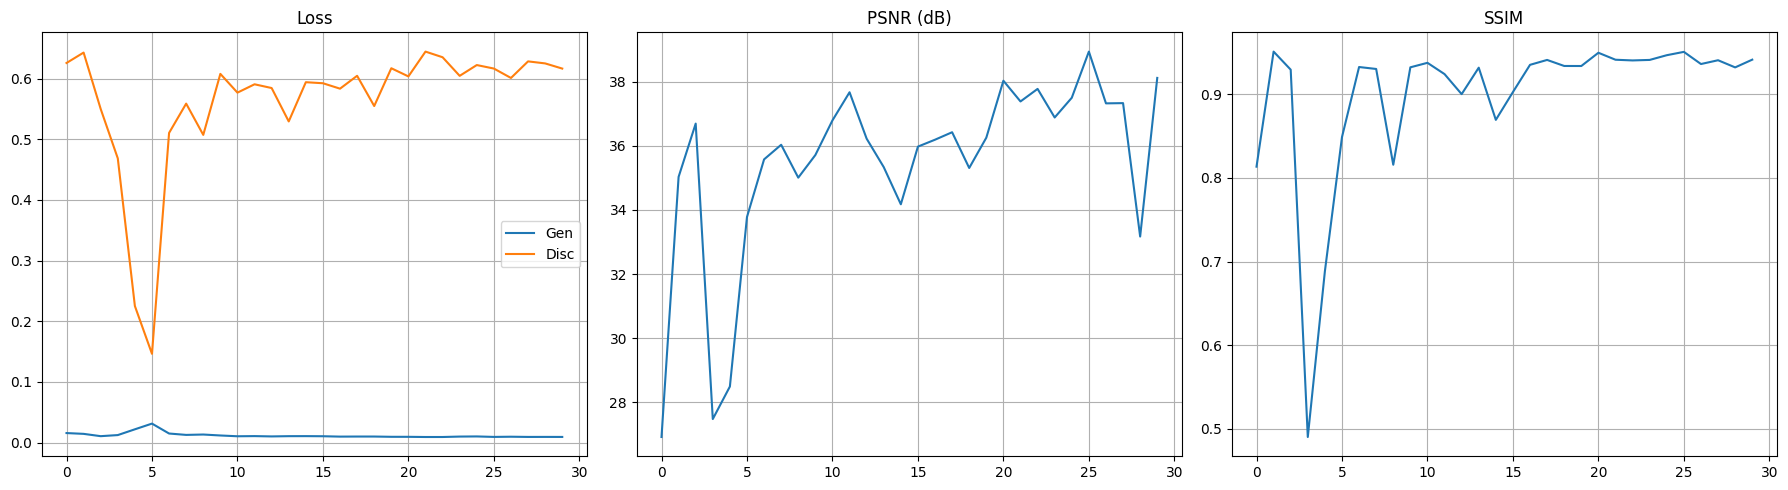

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(hist['g'], label='Gen')
ax[0].plot(hist['d'], label='Disc')
ax[0].set_title('Loss')
ax[0].legend()
ax[0].grid()

ax[1].plot(hist['psnr'])
ax[1].set_title('PSNR (dB)')
ax[1].grid()

ax[2].plot(hist['ssim'])
ax[2].set_title('SSIM')
ax[2].grid()

plt.tight_layout()
plt.savefig("curves_VIA.png", dpi=150)
plt.show()

Test Model

FINAL METRICS — Simulated Data (75→150)
  Method                      MSE       PSNR       SSIM
  Bicubic                0.000059      42.31     0.9736
  SRGAN (ours)           0.000326      35.03     0.9510


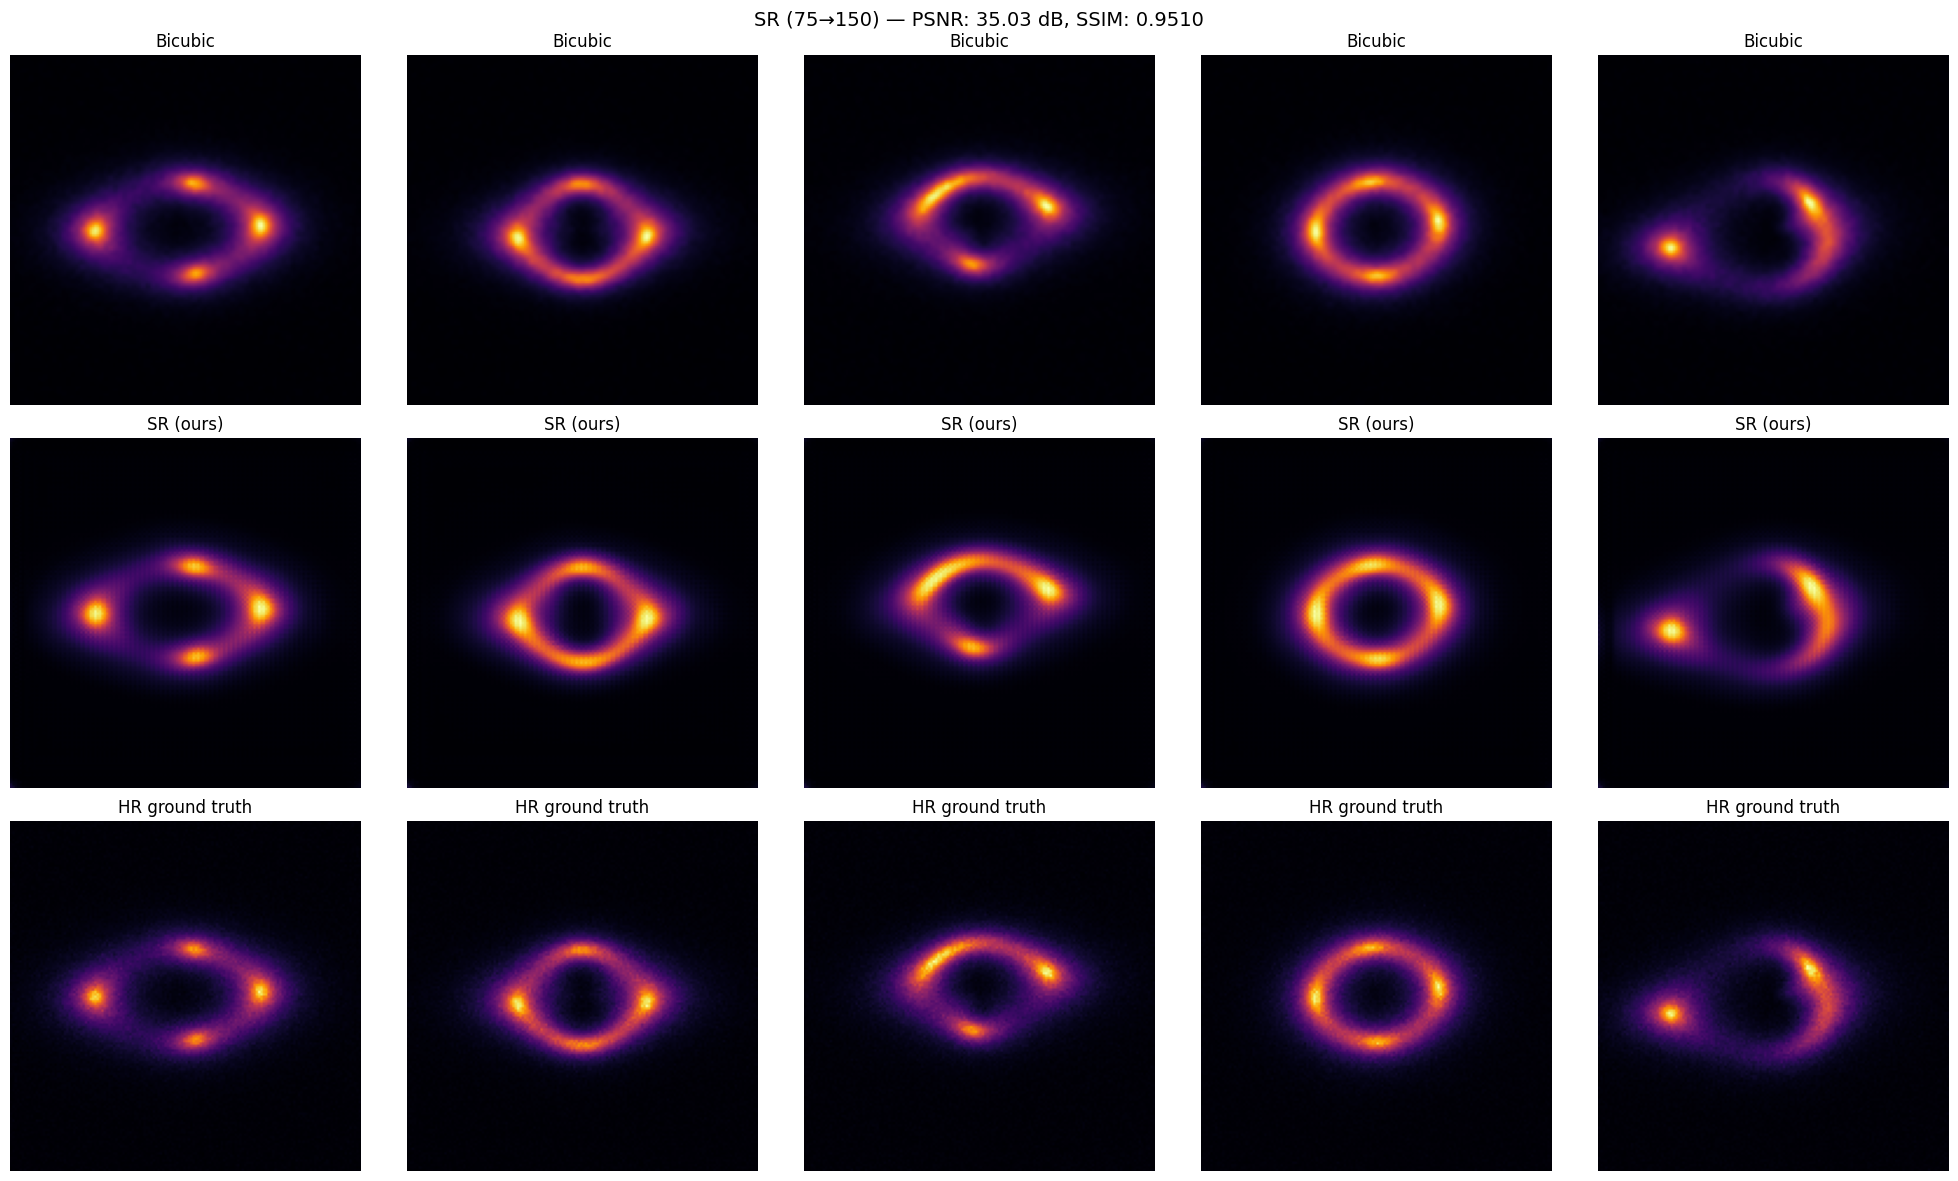

Saved: generator_simulated_final.keras


In [9]:
generator.load_weights("best_generator.weights.h5")
sr_test = generator.predict(lr_test, verbose=0)
mf, pf, sf = compute_metrics(hr_test, sr_test)

bic = np.clip(tf.image.resize(lr_test, [150, 150], method='bicubic').numpy(), 0, 1)
mb, pb, sb = compute_metrics(hr_test, bic)

print("=" * 55)
print("FINAL METRICS — Simulated Data (75→150)")
print("=" * 55)
print(f"  {'Method':<20s} {'MSE':>10s} {'PSNR':>10s} {'SSIM':>10s}")
print(f"  {'Bicubic':<20s} {mb:>10.6f} {pb:>10.2f} {sb:>10.4f}")
print(f"  {'SRGAN (ours)':<20s} {mf:>10.6f} {pf:>10.2f} {sf:>10.4f}")

n = 5
fig, axes = plt.subplots(3, n, figsize=(4*n, 12))
for i in range(n):
    j = np.random.randint(len(lr_test))
    lr_up = tf.image.resize(lr_test[j:j+1], [150, 150]).numpy()[0]
    axes[0,i].imshow(np.clip(lr_up[:,:,0],0,1), cmap='inferno')
    axes[0,i].set_title("Bicubic")
    axes[0,i].axis('off')
    axes[1,i].imshow(np.clip(sr_test[j,:,:,0],0,1), cmap='inferno')
    axes[1,i].set_title("SR (ours)")
    axes[1,i].axis('off')
    axes[2,i].imshow(hr_test[j,:,:,0], cmap='inferno')
    axes[2,i].set_title("HR ground truth")
    axes[2,i].axis('off')

plt.suptitle(f"SR (75→150) — PSNR: {pf:.2f} dB, SSIM: {sf:.4f}", fontsize=14)
plt.tight_layout()
plt.savefig("sr_results_simulated.png", dpi=150)
plt.show()

generator.save("generator_simulated_final.keras")
print("Saved: generator_simulated_final.keras")

Download Simulated Generator (Execute only if using Colab)

In [10]:
from google.colab import files
files.download("generator_simulated_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>